# Reproducible Visualization of Model Evaluation and Interpretability Analyses

This tutorial provides a **fully reproducible, modular visualization pipeline** for evaluating model performance, robustness, and interpretability in RNA–protein interaction studies. 

## Contents Overview

### 2. Evaluation of BRIDGE’s robustness across varying class imbalance scenarios
- Composite figures combining:
  - Method labels.
  - Dot-based heatmaps with overlaid numeric values.
  - Ranked summary bar plots.
- Emphasis on **comparability across imbalance scenarios**.
- Modular panel construction and final assembly using grid-based layouts.

```{note}
Please download the pre-computed results from `Figshare` first, and place them in the expected directory.
```

## Evaluation of BRIDGE’s robustness across varying class imbalance scenarios

```{note}
We will draw a composite figure with three aligned panels:

(1) Method names (left)

(2) Dot-heatmap: metric values across imbalance experiments (middle)

(3) Horizontal bar: average score per method (right)

Expected input files
1) mydata_inR.csv
   - A long table (recommended).
   - Must include columns:
       Method      : method name (factor/order matters)
       exprement   : imbalance setting / experiment label (x-axis categories)
       value       : numeric metric value displayed as dot color + text
       color_label : text color label for the value text (e.g. "white"/"black")

2) mydata_avg.csv
   - A table with columns:
       Method : method name (should match df$Method)
       val    : numeric average score per method

Notes:
- The ordering of Method in df controls the y-axis order.
- exprement is shown on the top axis (discrete).
```

In [8]:
# tidyverse / ggplot2 should already be loaded in earlier tutorial.
library(ggplot2)
library(ggnewscale)     # new_scale_color()
library(RColorBrewer)   # brewer.pal()
library(patchwork)      # p1 + p2 + p3 layout


In [9]:
# Helper: continuous palette ------------------------------------------------
paletteContinuous <- function(pal, n = 256, reverse = FALSE) {
  #' Generate a continuous palette from a set of colors.
  #'
  #' Parameters
  #' ----------
  #' pal : character vector
  #'   Vector of colors used as anchors for interpolation.
  #' n : integer
  #'   Number of colors returned.
  #' reverse : logical
  #'   If TRUE, reverse the resulting palette.
  #'
  #' Returns
  #' -------
  #' A character vector of length n.
  
  out <- colorRampPalette(pal)(n)
  if (isTRUE(reverse)) out <- rev(out)
  out
}


In [ ]:
# Read input data ----------------------------------------------------------
df <- read.csv(
  "../ablation&interpretability/mydata_inR.csv",
  row.names = "X",
  stringsAsFactors = FALSE
)

dt <- read.csv(
  "../ablation&interpretability/mydata_avg.csv",
  row.names = "X",
  stringsAsFactors = FALSE
)

# Basic cleanup ------------------------------------------------------------
dt$val <- round(dt$val, 3)

# Quick validation (fail early) -------------------------------------------
required_df <- c("Method", "exprement", "value", "color_label")
missing_df  <- setdiff(required_df, colnames(df))
if (length(missing_df) > 0) {
  stop("df is missing required columns: ", paste(missing_df, collapse = ", "))
}

required_dt <- c("Method", "val")
missing_dt  <- setdiff(required_dt, colnames(dt))
if (length(missing_dt) > 0) {
  stop("dt is missing required columns: ", paste(missing_dt, collapse = ", "))
}

# Ensure types are correct -------------------------------------------------
df$value <- as.numeric(df$value)
dt$val   <- as.numeric(dt$val)

# Optional: lock method order so all panels align --------------------------
# Use df$Method appearance order (or use dt$Method if you prefer).
method_levels <- unique(df$Method)
df$Method <- factor(df$Method, levels = method_levels)
dt$Method <- factor(dt$Method, levels = method_levels)


In [11]:
# Palettes -----------------------------------------------------------------
# Dot color palette (continuous)
pal <- c(
  brewer.pal(n = 11, name = "PRGn")[1:6],
  rev(brewer.pal(n = 11, name = "RdYlBu")[2:5])
)

# Bar ranking palette (continuous)
mycolors <- rev(colorRampPalette(pal[6:10])(nrow(dt)))

# Text colors for labels (must match df$color_label values)
text_color_map <- c("white" = "white", "black" = "black")


In [12]:
# Panel 1: method names ----------------------------------------------------
build_panel_methods <- function(df, text_size = 5) {
  #' Left panel: show method names aligned with y-axis grid.
  ggplot() +
    geom_text(
      aes(x = 0, y = df$Method, label = df$Method, hjust = 0),
      size = text_size
    ) +
    theme_light() +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    theme(
      panel.grid      = element_blank(),
      plot.background = element_blank(),
      axis.title      = element_blank(),
      axis.ticks      = element_blank(),
      axis.text       = element_blank(),
      panel.border    = element_blank(),
      plot.margin     = margin(),
      axis.ticks.length = unit(0, "mm")
    )
}

# Panel 2: dot-heatmap -----------------------------------------------------
build_panel_dotheat <- function(df, pal, text_color_map,
                                point_size = 20, label_size = 5) {
  #' Middle panel: dot heatmap (color=value) + numeric labels.
  #' Uses ggnewscale so labels can have a separate discrete color scale.
  
  ggplot(df, aes(x = exprement, y = Method)) +
    geom_point(aes(color = value), size = point_size) +
    scale_color_gradientn(colors = pal) +
    ggnewscale::new_scale_color() +
    geom_text(aes(label = round(value, 2), color = color_label),
              size = label_size) +
    scale_color_manual(values = text_color_map) +
    theme_minimal() +
    theme(
      panel.grid      = element_blank(),
      axis.title.x    = element_blank(),
      axis.ticks.x    = element_blank(),
      axis.title.y    = element_blank(),
      axis.text.x     = element_text(size = 18, colour = "black",
                                     hjust = 0.4, face = "bold", angle = 0),
      axis.text.y     = element_blank(),
      legend.position = "none",
      plot.margin     = margin(),
      axis.ticks.length = unit(0, "mm")
    ) +
    scale_y_discrete(position = "left") +
    scale_x_discrete(position = "top")
}

# Panel 3: average bar -----------------------------------------------------
build_panel_avgbar <- function(dt, mycolors, bar_width = 0.5, label_size = 6) {
  #' Right panel: horizontal bar showing average value per method.
  
  ggplot(dt, aes(x = Method, y = val, fill = val, group = factor(1))) +
    geom_bar(stat = "identity", width = bar_width) +
    geom_text(aes(label = sprintf("%0.2f", round(val, 2))),
              hjust = 1.3, size = label_size) +
    coord_flip() +
    xlab(NULL) + ylab(NULL) +
    scale_y_continuous(
      limits = c(0, 1.1),
      breaks = seq(0, 1, by = 0.5),
      labels = c("", "Average", ""),
      position = "right"
    ) +
    theme_bw() +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border     = element_blank(),
      legend.position  = "none",
      axis.text        = element_blank(),
      axis.ticks       = element_blank(),
      axis.text.x      = element_text(size = 15, colour = "black",
                                      hjust = 0.5, face = "plain",
                                      margin = margin(l = -10)),
      plot.margin      = margin(),
      axis.ticks.length.y = unit(0, "mm")
    ) +
    scale_fill_gradientn(
      colors = rev(mycolors),
      name   = "Ranking",
      limits = c(min(dt$val, na.rm = TRUE), 1),
      breaks = c(min(dt$val, na.rm = TRUE), 1),
      labels = c(length(dt$Method), 1)
    )
}


In [13]:
# Assemble figure ----------------------------------------------------------
# We add dotted separators so all three panels align visually.

build_robustness_figure <- function(df, dt, pal, mycolors, text_color_map,
                                    widths = c(0.8, 5.5, 2)) {
  #' Create the final composite plot (method names + dot heatmap + avg bar).
  #' Returns a patchwork object (can be printed and saved).
  
  p1 <- build_panel_methods(df)
  p2 <- build_panel_dotheat(df, pal, text_color_map)
  p3 <- build_panel_avgbar(dt, mycolors)
  
  # Add dotted grid lines between methods ----------------------------------
  n_methods <- length(levels(df$Method))
  
  for (i in seq_len(n_methods - 1)) {
    p3 <- p3 + geom_vline(xintercept = i + 0.5, linetype = "dotted", linewidth = 1)
    p2 <- p2 + geom_hline(yintercept = i + 0.5, linetype = "dotted", linewidth = 1)
    p1 <- p1 + geom_hline(yintercept = i + 0.5, linetype = "dotted", linewidth = 1)
  }
  
  # Add outer border lines (solid) -----------------------------------------
  p1 <- p1 + geom_hline(yintercept = n_methods + 0.5, linetype = "solid", linewidth = 1) +
    geom_hline(yintercept = 0.5, linetype = "solid", linewidth = 1)
  
  p2 <- p2 + geom_hline(yintercept = n_methods + 0.5, linetype = "solid", linewidth = 1) +
    geom_hline(yintercept = 0.5, linetype = "solid", linewidth = 1)
  
  p3 <- p3 + geom_vline(xintercept = n_methods + 0.5, linetype = "solid", linewidth = 1) +
    geom_vline(xintercept = 0.5, linetype = "solid", linewidth = 1) +
    geom_segment(aes(x = 0.5, y = 0, xend = n_methods + 0.5, yend = 0),
                 linetype = "solid", linewidth = 1)
  
  # Combine with patchwork -------------------------------------------------
  (p1 + p2 + p3) + patchwork::plot_layout(byrow = TRUE, widths = widths)
}


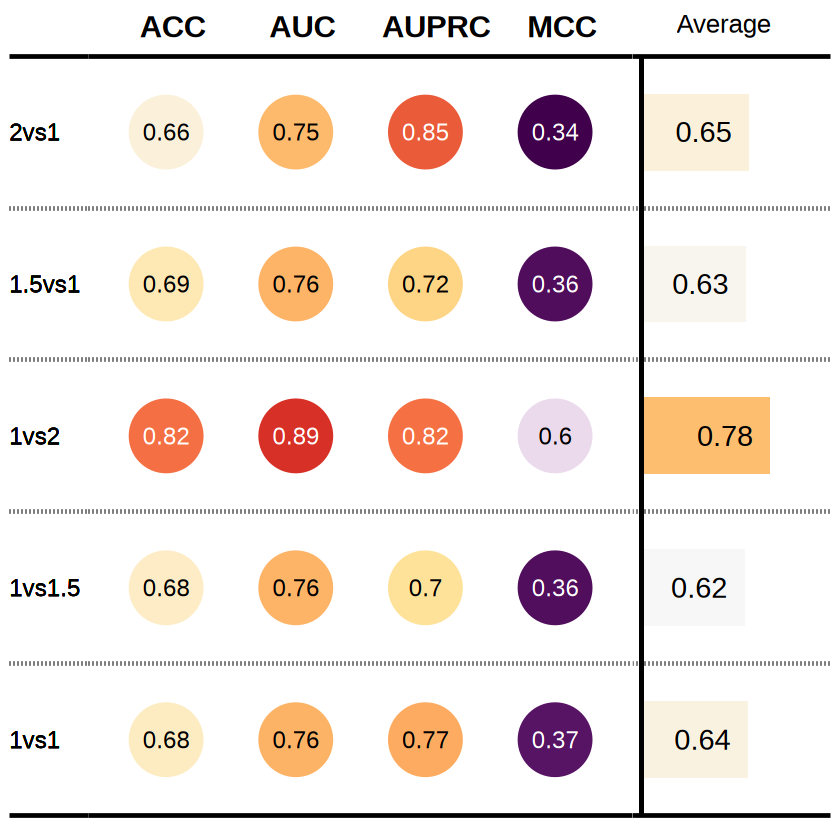

In [14]:
# Draw plot in notebook ----------------------------------------------------
p <- build_robustness_figure(df, dt, pal, mycolors, text_color_map)
print(p)
